### INITIALIZATION & ENVIRONMENT SETUP

In [2]:
# Core numerical, data manipulation and visualization frameworks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

%matplotlib inline
sns.set_style('darkgrid')

In [3]:
# Load transformed and feature-engineered dataset
data = pd.read_csv('../data/bank_churn_data_cleaned.csv',
                   dtype={'CustomerId': str})

df = pd.DataFrame(data)
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreTier,BalanceSegment,SalaryGroup
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adults,Fair,Zero,Medium-High
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adults,Fair,Medium,Medium-High
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adults,Poor,High,Medium-High
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Adults,Good,Zero,Medium-Low
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adults,Exceptional,Medium,Medium-Low


### BIVARIATE ANALYSIS

In [4]:
# Output baseline customer attrition proportion breakdown
churn_base = df['Exited'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
churn_base

Exited
0    79.63%
1    20.37%
Name: proportion, dtype: str

In [5]:
# Output geographical and gender churn percentages
region_churn = df.groupby('Geography')['Exited'].mean().mul(100).round(2).reset_index()
region_churn['Exited'] = region_churn['Exited'].astype(str) + '%'
print(region_churn)

print('='*175)

gender_churn = df.groupby('Gender')['Exited'].mean().mul(100).round(2).reset_index()
gender_churn['Exited'] = gender_churn['Exited'].astype(str) + '%'
print(gender_churn)

  Geography  Exited
0    France  16.15%
1   Germany  32.44%
2     Spain  16.67%
   Gender  Exited
0  Female  25.07%
1    Male  16.46%


In [6]:
# Output multi-index table for geographic and gender intersections
reg_gend_multi = df.groupby(['Geography', 'Gender'])['Exited'].mean().mul(100).round(2).reset_index()
reg_gend_multi['Exited'] = reg_gend_multi['Exited'].astype(str) + '%'
reg_gend_multi

,Geography,Gender,Exited
0,France,Female,20.34%
1,France,Male,12.71%
2,Germany,Female,37.55%
3,Germany,Male,27.81%
4,Spain,Female,21.21%
5,Spain,Male,13.11%


In [7]:
# Output raw volume counts alongside relative attrition across age brackets
age_count = df['AgeGroup'].value_counts().reset_index()
print(age_count)

age_exit = df.groupby('AgeGroup')['Exited'].mean().mul(100).round(2).sort_values(ascending=False).reset_index()
age_exit['Exited'] = age_exit['Exited'].astype(str) + '%'
age_exit

       AgeGroup  count
0        Adults   5921
1  Young Adults   1968
2  Older Adults   1647
3       Seniors    464


,AgeGroup,Exited
0,Older Adults,51.12%
1,Seniors,24.78%
2,Adults,15.74%
3,Young Adults,7.52%


In [8]:
# Output life stage attrition trends across identity groups
age_gen_exit = df.groupby(['AgeGroup', 'Gender'])['Exited'].mean().mul(100).round(2).reset_index()
age_gen_exit['Exited'] = age_gen_exit['Exited'].astype(str) + '%'
age_gen_exit

,AgeGroup,Gender,Exited
0,Adults,Female,19.67%
1,Adults,Male,12.6%
2,Older Adults,Female,57.3%
3,Older Adults,Male,44.97%
4,Seniors,Female,30.05%
5,Seniors,Male,20.32%
6,Young Adults,Female,9.89%
7,Young Adults,Male,5.61%


In [9]:
# Output localized branch churn across different age segments
geo_age = df.groupby(['Geography', 'AgeGroup'])['Exited'].mean().mul(100).round(2).reset_index()
geo_age['Exited'] = geo_age['Exited'].astype(str) + '%'
geo_age

,Geography,AgeGroup,Exited
0,France,Adults,12.35%
1,France,Older Adults,45.79%
2,France,Seniors,19.91%
3,France,Young Adults,4.91%
4,Germany,Adults,26.09%
5,Germany,Older Adults,67.33%
6,Germany,Seniors,38.94%
7,Germany,Young Adults,12.36%
8,Spain,Adults,12.53%
9,Spain,Older Adults,40.66%


In [10]:
# Output allocation frequencies of credit health ranking tiers
df['CreditScoreTier'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

CreditScoreTier
Fair           33.31%
Good           24.28%
Poor           23.62%
Very Good      12.24%
Exceptional     6.55%
Name: proportion, dtype: str

In [11]:
# Output customer exit probability across credit risk scores
credit_exit = df.groupby('CreditScoreTier')['Exited'].mean().mul(100).round(2).reset_index()
credit_exit['Exited'] = credit_exit['Exited'].astype(str) + '%'
credit_exit

,CreditScoreTier,Exited
0,Exceptional,19.54%
1,Fair,20.56%
2,Good,18.62%
3,Poor,22.02%
4,Very Good,20.59%


In [12]:
# Output attrition velocities based on account tenure
Tenure_exit = df.groupby('Tenure')['Exited'].mean().mul(100).round(2).reset_index()
Tenure_exit['Exited'] = Tenure_exit['Exited'].astype(str) + '%'
Tenure_exit

,Tenure,Exited
0,0,23.0%
1,1,22.42%
2,2,19.18%
3,3,21.11%
4,4,20.53%
5,5,20.65%
6,6,20.27%
7,7,17.22%
8,8,19.22%
9,9,21.65%


In [13]:
# Output baseline volume concentrations for banking products
df['NumOfProducts'].value_counts().reset_index()

,NumOfProducts,count
0,1,5084
1,2,4590
2,3,266
3,4,60


In [14]:
# Output cross-selling product threshold performance
prod_exit = df.groupby('NumOfProducts')['Exited'].mean().mul(100).round(2).reset_index()
prod_exit['Exited'] = prod_exit['Exited'].astype(str) + '%'
prod_exit

,NumOfProducts,Exited
0,1,27.71%
1,2,7.58%
2,3,82.71%
3,4,100.0%


In [15]:
# Output card ownership and activity conversion rates
card_exit = df.groupby('HasCrCard')['Exited'].mean().mul(100).round(2).reset_index()
card_exit['Exited'] = card_exit['Exited'].astype(str) + '%'
print(card_exit)

print('='*175)

active_churn = df.groupby('IsActiveMember')['Exited'].mean().mul(100).round(2).reset_index()
active_churn['Exited'] = active_churn['Exited'].astype(str) + '%'
print(active_churn)

   HasCrCard  Exited
0          0  20.81%
1          1  20.18%
   IsActiveMember  Exited
0               0  26.85%
1               1  14.27%


In [16]:
# Output multi-index table for active status and credit card ownership intersections
active_card_churn = df.groupby(['IsActiveMember', 'HasCrCard'])['Exited'].mean().mul(100).round(2).reset_index()
active_card_churn['Exited'] = active_card_churn['Exited'].astype(str) + '%'
active_card_churn

,IsActiveMember,HasCrCard,Exited
0,0,0,25.7%
1,0,1,27.32%
2,1,0,16.39%
3,1,1,13.36%


In [17]:
# Output raw volume counts cross balance segments
df['BalanceSegment'].value_counts().reset_index()

,BalanceSegment,count
0,Medium,5339
1,Zero,3617
2,High,969
3,Low,75


In [18]:
# Output attrition velocities against balance segments
bal_churn = df.groupby('BalanceSegment')['Exited'].mean().mul(100).round(2).reset_index()
bal_churn['Exited'] = bal_churn['Exited'].astype(str) + '%'
bal_churn

,BalanceSegment,Exited
0,High,23.12%
1,Low,34.67%
2,Medium,24.11%
3,Zero,13.82%


In [19]:
# Output attrition velocities against salary groups
salary_churn = df.groupby('SalaryGroup')['Exited'].mean().mul(100).round(2).reset_index()
salary_churn['Exited'] = salary_churn['Exited'].astype(str) + '%'
salary_churn

,SalaryGroup,Exited
0,High,21.56%
1,Low,20.0%
2,Medium-High,20.12%
3,Medium-Low,19.8%


#### ADVANCED MULTIVARIATE ANALYSIS

In [20]:
# Output multi-index table for age group and product intersections
age_prod_churn = df.groupby(['AgeGroup', 'NumOfProducts'])['Exited'].mean().mul(100).round(2).reset_index()
age_prod_churn['Exited'] = age_prod_churn['Exited'].astype(str) + '%'
age_prod_churn

,AgeGroup,NumOfProducts,Exited
0,Adults,1,21.47%
1,Adults,2,5.91%
2,Adults,3,78.68%
3,Adults,4,100.0%
4,Older Adults,1,60.9%
5,Older Adults,2,23.57%
6,Older Adults,3,98.78%
7,Older Adults,4,100.0%
8,Seniors,1,30.12%
9,Seniors,2,12.76%


In [21]:
# Output multi-index table for geographic and product intersections
geo_prod_churn = df.groupby(['Geography', 'NumOfProducts'])['Exited'].mean().mul(100).round(2).reset_index()
geo_prod_churn['Exited'] = geo_prod_churn['Exited'].astype(str) + '%'
geo_prod_churn

,Geography,NumOfProducts,Exited
0,France,1,22.43%
1,France,2,5.7%
2,France,3,78.85%
3,France,4,100.0%
4,Germany,1,42.85%
5,Germany,2,12.12%
6,Germany,3,89.58%
7,Germany,4,100.0%
8,Spain,1,21.87%
9,Spain,2,7.35%


In [22]:
# Output gender churn responses under multi-product holdings
gender_prod_churn = df.groupby(['Gender', 'NumOfProducts'])['Exited'].mean().mul(100).round(2).reset_index()
gender_prod_churn['Exited'] = gender_prod_churn['Exited'].astype(str) + '%'
gender_prod_churn

,Gender,NumOfProducts,Exited
0,Female,1,33.19%
1,Female,2,10.19%
2,Female,3,86.58%
3,Female,4,100.0%
4,Male,1,23.21%
5,Male,2,5.45%
6,Male,3,77.78%
7,Male,4,100.0%


In [23]:
# Output balance segment interactions cross-referenced with salary groups
bal_sal_churn = df.groupby(['BalanceSegment', 'SalaryGroup'])['Exited'].mean().mul(100).round(2).reset_index()
bal_sal_churn['Exited'] = bal_sal_churn['Exited'].astype(str) + '%'
bal_sal_churn

,BalanceSegment,SalaryGroup,Exited
0,High,High,25.73%
1,High,Low,21.51%
2,High,Medium-High,24.1%
3,High,Medium-Low,21.05%
4,Low,High,40.0%
5,Low,Low,26.67%
6,Low,Medium-High,35.29%
7,Low,Medium-Low,34.78%
8,Medium,High,25.0%
9,Medium,Low,24.56%


In [24]:
# Output balance behavior conditioned by active membership status
bal_active_churn = df.groupby(['BalanceSegment', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).reset_index()
bal_active_churn['Exited'] = bal_active_churn['Exited'].astype(str) + '%'
bal_active_churn

,BalanceSegment,IsActiveMember,Exited
0,High,0,29.96%
1,High,1,16.29%
2,Low,0,51.43%
3,Low,1,20.0%
4,Medium,0,31.67%
5,Medium,1,17.0%
6,Zero,0,18.35%
7,Zero,1,9.61%


In [25]:
# Output credit card possession volumes grouped by activity status
df.groupby(['IsActiveMember', 'HasCrCard'])['CustomerId'].count()

IsActiveMember  HasCrCard
0               0            1401
                1            3448
1               0            1544
                1            3607
Name: CustomerId, dtype: int64

In [26]:
# Output customer distributions across product bundles and active interaction states
df.groupby(['IsActiveMember', 'NumOfProducts'])['CustomerId'].count()

IsActiveMember  NumOfProducts
0               1                2521
                2                2144
                3                 153
                4                  31
1               1                2563
                2                2446
                3                 113
                4                  29
Name: CustomerId, dtype: int64

In [27]:
# Output multi-index table for geographic and active status intersections
geo_active_churn = df.groupby(['Geography', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).reset_index()
geo_active_churn['Exited'] = geo_active_churn['Exited'].astype(str) + '%'
geo_active_churn

,Geography,IsActiveMember,Exited
0,France,0,21.13%
1,France,1,11.5%
2,Germany,0,41.08%
3,Germany,1,23.72%
4,Spain,0,23.35%
5,Spain,1,10.75%


In [28]:
# Output customer age bracket attrition rates split by activity indicators
age_active_churn = df.groupby(['AgeGroup', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).reset_index()
age_active_churn['Exited'] = age_active_churn['Exited'].astype(str) + '%'
age_active_churn

,AgeGroup,IsActiveMember,Exited
0,Adults,0,19.73%
1,Adults,1,11.62%
2,Older Adults,0,68.36%
3,Older Adults,1,35.35%
4,Seniors,0,82.02%
5,Seniors,1,11.2%
6,Young Adults,0,10.08%
7,Young Adults,1,5.07%


In [29]:
# Output demographic attrition rates conditioned on active membership status
gen_active_churn = df.groupby(['Gender', 'IsActiveMember'])['Exited'].mean().mul(100).round(2).reset_index()
gen_active_churn['Exited'] = gen_active_churn['Exited'].astype(str) + '%'
gen_active_churn

,Gender,IsActiveMember,Exited
0,Female,0,32.09%
1,Female,1,18.13%
2,Male,0,22.28%
3,Male,1,11.2%


In [30]:
# Output multi-index table for geographic and balance segment interactions
geo_bal_churn = df.groupby(['Geography', 'BalanceSegment'])['Exited'].mean().mul(100).round(2).reset_index()
geo_bal_churn['Exited'] = geo_bal_churn['Exited'].astype(str) + '%'
geo_bal_churn

,Geography,BalanceSegment,Exited
0,France,High,24.31%
1,France,Low,48.78%
2,France,Medium,16.39%
3,France,Zero,13.94%
4,Germany,High,19.11%
5,Germany,Low,0.0%
6,Germany,Medium,34.65%
7,Spain,High,26.46%
8,Spain,Low,40.0%
9,Spain,Medium,17.79%


In [31]:
# Output raw data records isolating anomalies in low-balance German customer brackets
german_low_balance_anomalies = df.loc[(df['Geography'] == 'Germany') & (df['BalanceSegment'] == 'Low')]
german_low_balance_anomalies.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreTier,BalanceSegment,SalaryGroup
257,15592979,Rose,671,Germany,Female,34,6,37266.67,2,0,0,156917.12,0,Adults,Good,Low,High
368,15684042,Blair,636,Germany,Male,34,2,40105.51,2,0,1,53512.16,0,Adults,Fair,Low,Medium-Low
1181,15624428,Longo,651,Germany,Female,24,7,40224.70,1,1,1,178341.33,0,Young Adults,Fair,Low,High
1579,15743976,Archer,618,Germany,Male,41,8,37702.79,1,1,1,195775.48,0,Adults,Fair,Low,High
2222,15763662,Longo,711,Germany,Male,43,2,39043.29,2,1,1,175423.69,0,Adults,Good,Low,High


In [32]:
# Output multi-index table for age group and balance segment intersections
age_bal_churn = df.groupby(['AgeGroup', 'BalanceSegment'])['Exited'].mean().mul(100).round(2).reset_index()
age_bal_churn['Exited'] = age_bal_churn['Exited'].astype(str) + '%'
age_bal_churn

,AgeGroup,BalanceSegment,Exited
0,Adults,High,18.02%
1,Adults,Low,28.89%
2,Adults,Medium,18.66%
3,Adults,Zero,10.58%
4,Older Adults,High,55.21%
5,Older Adults,Low,72.73%
6,Older Adults,Medium,55.65%
7,Older Adults,Zero,41.25%
8,Seniors,High,16.22%
9,Seniors,Low,50.0%


In [33]:
# Output gender churn responses inside balance concentration segments
gen_bal_churn = df.groupby(['Gender', 'BalanceSegment'])['Exited'].mean().mul(100).round(2).reset_index()
gen_bal_churn['Exited'] = gen_bal_churn['Exited'].astype(str) + '%'
gen_bal_churn

,Gender,BalanceSegment,Exited
0,Female,High,28.3%
1,Female,Low,46.51%
2,Female,Medium,29.27%
3,Female,Zero,17.53%
4,Male,High,19.08%
5,Male,Low,18.75%
6,Male,Medium,19.81%
7,Male,Zero,10.7%


In [34]:
# Output multi-index table for geographic and credit card ownership interactions
geo_card_churn = df.groupby(['Geography', 'HasCrCard'])['Exited'].mean().mul(100).round(2).reset_index()
geo_card_churn['Exited'] = geo_card_churn['Exited'].astype(str) + '%'
geo_card_churn

,Geography,HasCrCard,Exited
0,France,0,16.38%
1,France,1,16.06%
2,Germany,0,33.01%
3,Germany,1,32.22%
4,Spain,0,17.86%
5,Spain,1,16.15%


In [35]:
# Output demographic gender attrition against credit card status
gen_card_churn = df.groupby(['Gender', 'HasCrCard'])['Exited'].mean().mul(100).round(2).reset_index()
gen_card_churn['Exited'] = gen_card_churn['Exited'].astype(str) + '%'
gen_card_churn

,Gender,HasCrCard,Exited
0,Female,0,25.46%
1,Female,1,24.91%
2,Male,0,16.88%
3,Male,1,16.28%


In [36]:
# Output customer age group attrition cross-referenced with credit card status
age_card_churn = df.groupby(['AgeGroup', 'HasCrCard'])['Exited'].mean().mul(100).round(2).reset_index()
age_card_churn['Exited'] = age_card_churn['Exited'].astype(str) + '%'
age_card_churn

,AgeGroup,HasCrCard,Exited
0,Adults,0,15.3%
1,Adults,1,15.92%
2,Older Adults,0,54.23%
3,Older Adults,1,49.78%
4,Seniors,0,25.74%
5,Seniors,1,24.39%
6,Young Adults,0,7.39%
7,Young Adults,1,7.57%


#### VISUALIZATION & CORE PERFORMANCE EXECUTIVE DASHBOARD

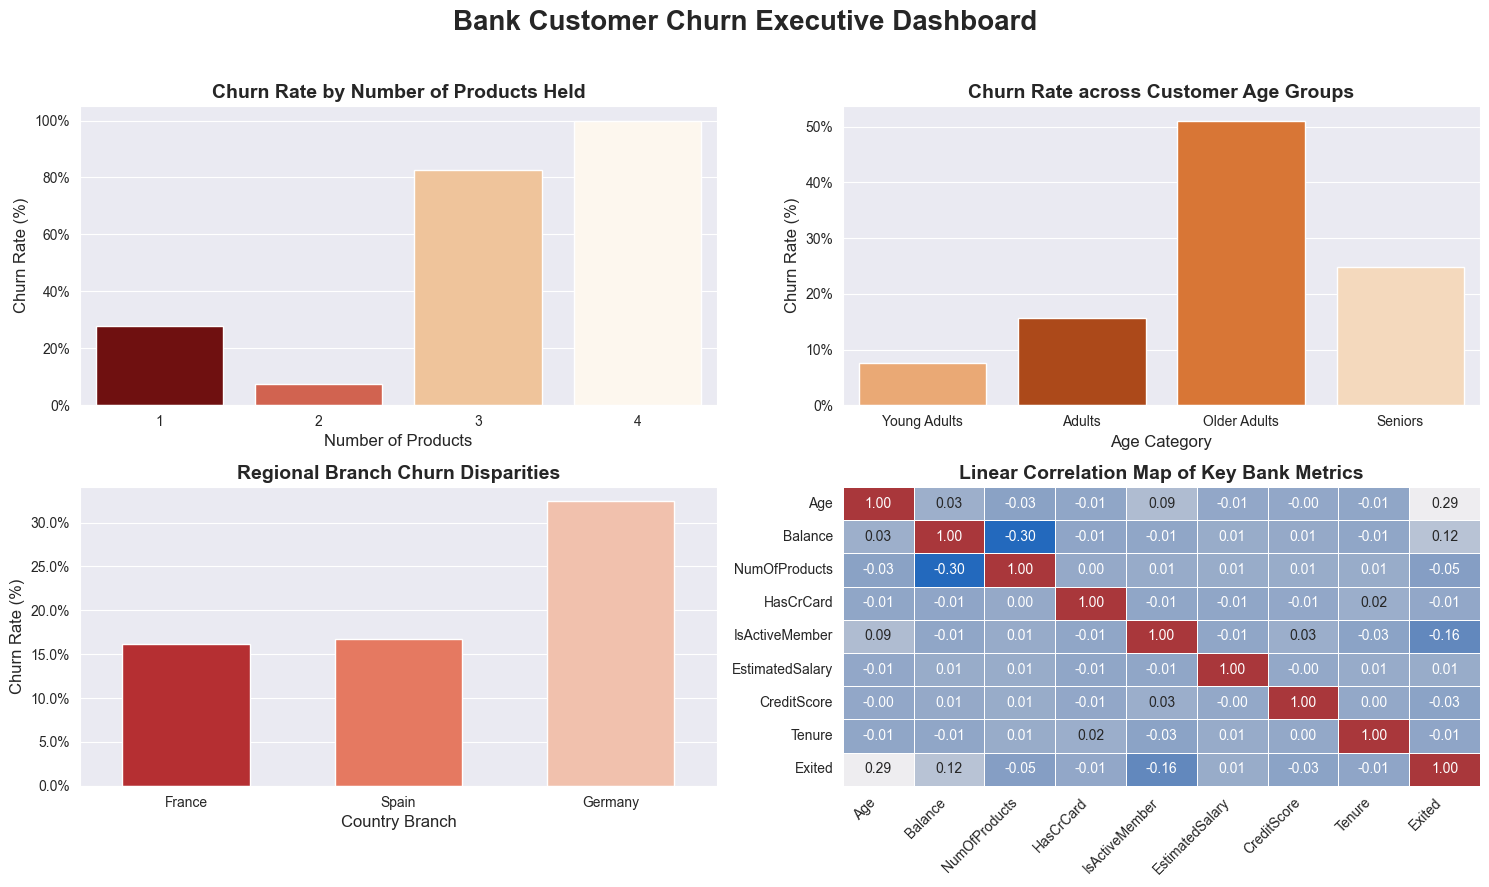

In [37]:
fig, axes = plt.subplots(2,2, figsize= (15, 9))
fig.suptitle('Bank Customer Churn Executive Dashboard', fontsize=20, weight='bold', y=0.98)

# TOP-LEFT: Number of Products (The Operational Risk)
sns.barplot(ax=axes[0,0], data=df, x='NumOfProducts', y='Exited', errorbar=None, palette='OrRd_r', hue='NumOfProducts', legend=False)
axes[0,0].set_title('Churn Rate by Number of Products Held', fontsize=14, weight='bold')
axes[0,0].set_xlabel('Number of Products', fontsize=12)
axes[0,0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# TOP-RIGHT: Age Group (The Core Demographic Risk)
age_order = ['Young Adults', 'Adults', 'Older Adults', 'Seniors']
sns.barplot(ax=axes[0,1], data=df, x='AgeGroup', y='Exited', order=age_order, errorbar=None, palette='Oranges_r', hue='AgeGroup')
axes[0,1].set_title('Churn Rate across Customer Age Groups', fontsize=14, weight='bold')
axes[0,1].set_xlabel('Age Category', fontsize=12)
axes[0,1].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# BOTTOM-LEFT: Geography (The Regional Leak)
sns.barplot(ax=axes[1,0], data=df, x='Geography', y='Exited', errorbar=None, palette='Reds_r', hue='Geography', width=0.6)
axes[1,0].set_title('Regional Branch Churn Disparities', fontsize=14, weight='bold')
axes[1,0].set_xlabel('Country Branch', fontsize=12)
axes[1,0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[1, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# BOTTOM-RIGHT: Linear Correlation Heatmap (Advanced Validation)
numeric_cols = ['Age', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'CreditScore', 'Tenure', 'Exited']
sns.heatmap(ax=axes[1,1], data=df[numeric_cols].corr(), annot=True, cmap='vlag', fmt='.2f', linewidths=0.5, cbar=False)
axes[1,1].set_title('Linear Correlation Map of Key Bank Metrics', fontsize=14, weight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../reports/customer_churn_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()